### Exploratory Data Analysis of CSK's IPL Performance (2008–2026)

In [1]:
# importing all the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
# Reading the csv file

ipl_data = pd.read_csv("../data/IPL_Matches_Data_2008_2026.csv")

# displaying the ipl_data 

ipl_data

,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,toss_decision,...,umpire2,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players
0,Indian Premier League,2007/08,1.0,18-04-2008,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,RE Koertzen,AM Saheba,VN Kulkarni,T20,20,6,male,club,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey..."
1,Indian Premier League,2007/08,2.0,19-04-2008,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,...,SL Shastri,RB Tiffin,MSS Ranawat,T20,20,6,male,club,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ..."
2,Indian Premier League,2007/08,3.0,19-04-2008,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,...,GA Pratapkumar,IL Howell,Unknown,T20,20,6,male,club,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm..."
3,Indian Premier League,2007/08,4.0,20-04-2008,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,...,K Hariharan,Asad Rauf,F Gomes,T20,20,6,male,club,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S..."
4,Indian Premier League,2007/08,5.0,20-04-2008,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,...,DJ Harper,AV Jayaprakash,SN Bandekar,T20,20,6,male,club,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1238,Indian Premier League,2026,70.0,24-05-2026,Kolkata,"Eden Gardens, Kolkata",Delhi Capitals,Kolkata Knight Riders,Kolkata Knight Riders,field,...,HAS Khalid,SJ Nogajski,M Krishnadas,T20,20,6,male,club,"Kuldeep Yadav, Abishek Porel, KL Rahul, SU Par...","SP Narine, AM Rahane, FH Allen, MK Pandey, C G..."
1239,Indian Premier League,2026,NaN,26-05-2026,Dharamsala,"Himachal Pradesh Cricket Association Stadium, ...",Royal Challengers Bengaluru,Gujarat Titans,Gujarat Titans,field,...,VK Sharma,Nitin Menon,KN Ananthapadmanabhan,T20,20,6,male,club,"R Shepherd, VR Iyer, V Kohli, D Padikkal, RM P...","K Khejroliya, B Sai Sudharsan, Shubman Gill, J..."
1240,Indian Premier League,2026,NaN,27-05-2026,New Chandigarh,Maharaja Yadavindra Singh International Cricke...,Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,...,UV Gandhe,R Pandit,SJ Nogajski,T20,20,6,male,club,"YBK Jaiswal, V Suryavanshi, Dhruv Jurel, R Par...","PP Hinge, Abhishek Sharma, TM Head, Ishan Kish..."
1241,Indian Premier League,2026,NaN,29-05-2026,New Chandigarh,Maharaja Yadavindra Singh International Cricke...,Rajasthan Royals,Gujarat Titans,Rajasthan Royals,bat,...,SJ Nogajski,AT Holdstock,UV Gandhe,T20,20,6,male,club,"TU Deshpande, YBK Jaiswal, V Suryavanshi, Dhru...","Mohammed Siraj, B Sai Sudharsan, Shubman Gill,..."


In [3]:
# understanding the data what is given or provided

ipl_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_name       1243 non-null   str    
 1   season           1243 non-null   str    
 2   match_number     1169 non-null   float64
 3   date             1243 non-null   str    
 4   city             1243 non-null   str    
 5   venue            1243 non-null   str    
 6   team1            1243 non-null   str    
 7   team2            1243 non-null   str    
 8   toss_winner      1243 non-null   str    
 9   toss_decision    1243 non-null   str    
 10  team1_runs       1243 non-null   int64  
 11  team1_wickets    1243 non-null   int64  
 12  team2_runs       1243 non-null   int64  
 13  team2_wickets    1243 non-null   int64  
 14  winner           1218 non-null   str    
 15  result_type      1243 non-null   str    
 16  win_by_runs      1243 non-null   int64  
 17  win_by_wickets   1243 non

#### Dropping the unecessary columns that are not relevant for analysis

In [4]:
# Removing columns that are not required for CSK performance analysis.

ipl_data.drop(
    [
        "event_name",
        "match_number",
        "city",
        "match_referee",
        "umpire1",
        "umpire2",
        "tv_umpire",
        "reserve_umpire",
        "match_type",
        "overs_limit",
        "balls_per_over",
        "gender",
        "team_type",
        "team1_players",
        "team2_players",
    ],
    axis=1,
    inplace=True,
)  
# axis=1 -> operates on columns
# inplace=True -> applies the changes directly to the original DataFrame

In [5]:
# updated ipl_data

ipl_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   season           1243 non-null   str  
 1   date             1243 non-null   str  
 2   venue            1243 non-null   str  
 3   team1            1243 non-null   str  
 4   team2            1243 non-null   str  
 5   toss_winner      1243 non-null   str  
 6   toss_decision    1243 non-null   str  
 7   team1_runs       1243 non-null   int64
 8   team1_wickets    1243 non-null   int64
 9   team2_runs       1243 non-null   int64
 10  team2_wickets    1243 non-null   int64
 11  winner           1218 non-null   str  
 12  result_type      1243 non-null   str  
 13  win_by_runs      1243 non-null   int64
 14  win_by_wickets   1243 non-null   int64
 15  player_of_match  1234 non-null   str  
dtypes: int64(6), str(10)
memory usage: 155.5 KB


#### Extracting the CSK Data from the ipl data set for CSK Analysis

In [6]:
csk_data = ipl_data[(ipl_data["team1"]== "Chennai Super Kings") | (ipl_data["team2"]== "Chennai Super Kings")]

In [7]:
# basic information about the csk_data DataFrame

csk_data.info()

<class 'pandas.DataFrame'>
Index: 266 entries, 1 to 1234
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   season           266 non-null    str  
 1   date             266 non-null    str  
 2   venue            266 non-null    str  
 3   team1            266 non-null    str  
 4   team2            266 non-null    str  
 5   toss_winner      266 non-null    str  
 6   toss_decision    266 non-null    str  
 7   team1_runs       266 non-null    int64
 8   team1_wickets    266 non-null    int64
 9   team2_runs       266 non-null    int64
 10  team2_wickets    266 non-null    int64
 11  winner           264 non-null    str  
 12  result_type      266 non-null    str  
 13  win_by_runs      266 non-null    int64
 14  win_by_wickets   266 non-null    int64
 15  player_of_match  265 non-null    str  
dtypes: int64(6), str(10)
memory usage: 35.3 KB


In [8]:
# checking the datatypes of csk_data's columns

csk_data.dtypes

season               str
date                 str
venue                str
team1                str
team2                str
toss_winner          str
toss_decision        str
team1_runs         int64
team1_wickets      int64
team2_runs         int64
team2_wickets      int64
winner               str
result_type          str
win_by_runs        int64
win_by_wickets     int64
player_of_match      str
dtype: object

In [9]:
# Checking the duplicate rows

csk_data.duplicated().sum()

np.int64(0)

### Season-wise Results

A separate season-level dataset is created to record CSK's final outcome in each IPL season.

In [10]:
# Creating a season-level dataset to store CSK's final result for each season.

season_data = {
    "2008": {"league_stage": 2, "playoffs": True, "final_result": "Runner-up"},
    "2009": {"league_stage": 2, "playoffs": True, "final_result": "Semi-finalist"},
    "2010": {"league_stage": 3, "playoffs": True, "final_result": "Champion"},
    "2011": {"league_stage": 2, "playoffs": True, "final_result": "Champion"},
    "2012": {"league_stage": 4, "playoffs": True, "final_result": "Runner-up"},
    "2013": {"league_stage": 2, "playoffs": True, "final_result": "Runner-up"},
    "2014": {"league_stage": 3, "playoffs": True, "final_result": "Playoff exit"},
    "2015": {"league_stage": 1, "playoffs": True, "final_result": "Runner-up"},
    "2018": {"league_stage": 2, "playoffs": True, "final_result": "Champion"},
    "2019": {"league_stage": 2, "playoffs": True, "final_result": "Runner-up"},
    "2020": {"league_stage": 7, "playoffs": False, "final_result": "League stage"},
    "2021": {"league_stage": 2, "playoffs": True, "final_result": "Champion"},
    "2022": {"league_stage": 9, "playoffs": False, "final_result": "League stage"},
    "2023": {"league_stage": 2, "playoffs": True, "final_result": "Champion"},
    "2024": {"league_stage": 5, "playoffs": False, "final_result": "League stage"},
    "2025": {"league_stage": 10, "playoffs": False, "final_result": "League stage"},
    "2026": {"league_stage": 8, "playoffs": False, "final_result": "League stage"},
}

season_result = pd.DataFrame.from_dict(season_data,orient="index")

season_result

,league_stage,playoffs,final_result
2008,2,True,Runner-up
2009,2,True,Semi-finalist
2010,3,True,Champion
2011,2,True,Champion
2012,4,True,Runner-up
2013,2,True,Runner-up
2014,3,True,Playoff exit
2015,1,True,Runner-up
2018,2,True,Champion
2019,2,True,Runner-up


#### Checking and Handling the NaN values in csk_data

In [11]:
# checking the null values in csk_data

csk_data.isna().sum()

season             0
date               0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
team1_runs         0
team1_wickets      0
team2_runs         0
team2_wickets      0
winner             2
result_type        0
win_by_runs        0
win_by_wickets     0
player_of_match    1
dtype: int64

In [12]:
# Checking where the winner is NaN

csk_data[(csk_data["winner"].isna())]

,season,date,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,team2_runs,team2_wickets,winner,result_type,win_by_runs,win_by_wickets,player_of_match
130,2009/10,21-03-2010,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,field,145,9,146,9,NaN,tie,0,0,J Theron
994,2023,03-05-2023,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,125,7,0,0,NaN,no result,0,0,NaN


In [13]:
# checking where the player of match is missing

csk_data[(csk_data["player_of_match"].isna())]

,season,date,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,team2_runs,team2_wickets,winner,result_type,win_by_runs,win_by_wickets,player_of_match
994,2023,03-05-2023,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,125,7,0,0,NaN,no result,0,0,NaN


#### Data Cleaning & Preprocessing

In [14]:
# Standardizing season values for consistent season-wise analysis.
# Some seasons are represented as a two-year format (e.g., 2007/08, 2009/10, 2020/21),
# so they are converted into a single representative year.


csk_data["season"] = csk_data["season"].replace({
    "2007/08":"2008",
    "2009/10":"2010",
    "2020/21":"2020",
})

In [15]:
# Converting the date column from string to datetime format for accurate date-based analysis.

csk_data["date"] = pd.to_datetime(csk_data["date"],dayfirst=True)

In [16]:
# Standardizing historical team names to ensure consistent opponent-wise analysis.
# Some IPL teams have changed their official names over the years.

csk_data[(csk_data["team1"]== "Kings XI Punjab") | (csk_data["team2"]== "Kings XI Punjab")]

csk_data[["team1", "team2"]] = csk_data[["team1", "team2"]].replace("Kings XI Punjab", "Punjab Kings")

In [17]:
csk_data[(csk_data["team1"] == "Royal Challengers Bangalore") | (csk_data["team2"] == "Royal Challengers Bangalore")]

csk_data[["team1", "team2"]] = csk_data[["team1", "team2"]].replace("Royal Challengers Bangalore", "Royal Challengers Bengaluru")

In [18]:
csk_data[(csk_data["team1"] == "Delhi Daredevils") | (csk_data["team2"] == "Delhi Daredevils")]

csk_data[["team1", "team2"]] = csk_data[["team1", "team2"]].replace("Delhi Daredevils", "Delhi Capitals")

In [19]:
# Standardizing historical team names in the winner and toss_winner columns
# for consistent team-wise analysis.

csk_data[["winner", "toss_winner"]] = csk_data[["winner", "toss_winner"]].replace("Royal Challengers Bangalore", "Royal Challengers Bengaluru")

csk_data[["winner", "toss_winner"]] = csk_data[["winner", "toss_winner"]].replace("Kings XI Punjab","Punjab Kings")

csk_data[["winner", "toss_winner"]] = csk_data[["winner", "toss_winner"]].replace("Delhi Daredevils","Delhi Capitals")

In [101]:
venue_mapping = {
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium",
    "MA Chidambaram Stadium, Chepauk, Chennai": "MA Chidambaram Stadium",
    "Wankhede Stadium, Mumbai": "Wankhede Stadium",
    "M Chinnaswamy Stadium, Bengaluru": "M Chinnaswamy Stadium",
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "Eden Gardens, Kolkata": "Eden Gardens",
    "Arun Jaitley Stadium, Delhi": "Arun Jaitley Stadium",
    "Sawai Mansingh Stadium, Jaipur": "Sawai Mansingh Stadium",
    "Feroz Shah Kotla": "Arun Jaitley Stadium",
    "Maharashtra Cricket Association Stadium, Pune": "Maharashtra Cricket Association Stadium",
    "Dr DY Patil Sports Academy, Mumbai": "Dr DY Patil Sports Academy",
    "Rajiv Gandhi International Stadium": "Rajiv Gandhi International Stadium, Uppal",
    "Rajiv Gandhi International Stadium, Uppal, Hyderabad": "Rajiv Gandhi International Stadium, Uppal",
    "Brabourne Stadium, Mumbai": "Brabourne Stadium",
}

csk_data["venue"] = csk_data["venue"].replace(venue_mapping)

## Exploratory Data Analysis (EDA)

### Definition

EDA is the process of exploring, summarizing, and visualizing data to understand its structure, patterns, trends, and relationships.

### Purpose

* Understand the dataset and its variables.
* Identify patterns, trends, and relationships.
* Detect missing values, duplicates, and unusual observations.
* Generate meaningful insights from the data.

### Purpose in This Project

In this project, EDA is used to analyze **CSK's IPL performance from 2008–2026** by studying season-wise performance, wins and losses, batting and bowling performance, opponents, venues, and toss outcomes.

In [20]:
# Number of season played by CSK

print(f"Chennai Super Kings has played {season_result.shape[0]} seasons.")

Chennai Super Kings has played 17 seasons.


In [21]:
# Number of matches played by CSK in each season.
# CSK did not participate in the IPL during 2016 and 2017.

matches_played_per_season =  csk_data.groupby("season").size()

matches_played_per_season

season
2008    16
2009    14
2010    16
2011    16
2012    18
2013    18
2014    16
2015    17
2018    16
2019    17
2020    14
2021    16
2022    14
2023    16
2024    14
2025    14
2026    14
dtype: int64

In [22]:
# Number of times CSK reached to playoffs

print(f"Chennai Super Kings have qualified for the IPL playoffs {season_result[season_result['playoffs']].shape[0]} times.")

Chennai Super Kings have qualified for the IPL playoffs 12 times.


In [23]:
# Number of times CSK won the season

print(f"Chennai Super Kings have won {season_result[(season_result['final_result'] == 'Champion')].shape[0]} IPL trophies.")

Chennai Super Kings have won 5 IPL trophies.


In [24]:
# Number of times CSK finished as runners-up

print(f"Chennai Super Kings have finished as runners-up {season_result[season_result['final_result'] == 'Runner-up'].shape[0]} times.")

Chennai Super Kings have finished as runners-up 5 times.


In [25]:
# Number of times CSK failed to qualify

print(f"Chennai Super Kings did not qualify in {season_result[(season_result["final_result"]=="League stage")].shape[0]} times.")

Chennai Super Kings did not qualify in 5 times.


In [26]:
# Number of matches played by CSK

print(f"Chennai Super Kings have played {csk_data.shape[0]} matches.")

Chennai Super Kings have played 266 matches.


In [27]:
# Number of matches won by CSK

print(f"Chennai Super Kings has won {(csk_data["winner"]== "Chennai Super Kings").sum()} matches.")

Chennai Super Kings has won 148 matches.


In [28]:
# Number of matches lost by CSK

print(
    f"Chennai Super Kings has lost {((csk_data["winner"].notna()) & (csk_data["winner"] != "Chennai Super Kings")).sum()} matches."
)

Chennai Super Kings has lost 116 matches.


In [29]:
# Number of matches where result was not there (tie/no result)

no_result = int(csk_data["winner"].isna().sum())
print(f"Chennai Super Kings had {no_result} matches with no result.")

Chennai Super Kings had 2 matches with no result.


In [30]:
# Number of matches win in each season by CSK

won_matches_per_season = csk_data[csk_data["winner"]== "Chennai Super Kings"].groupby("season").size()
won_matches_per_season

season
2008     9
2009     8
2010     9
2011    11
2012    10
2013    12
2014    10
2015    10
2018    11
2019    10
2020     6
2021    11
2022     4
2023    10
2024     7
2025     4
2026     6
dtype: int64

In [31]:
# Number of matches lost in each season by CSK (excluding tie/ no result)

lost_matches_per_season = (
    csk_data[((csk_data["winner"].notna()) & (csk_data["winner"] != "Chennai Super Kings"))].groupby("season").size()
)
lost_matches_per_season

season
2008     7
2009     6
2010     6
2011     5
2012     8
2013     6
2014     6
2015     7
2018     5
2019     7
2020     8
2021     5
2022    10
2023     5
2024     7
2025    10
2026     8
dtype: int64

### Season-wise Win and Loss Percentage of CSK

In [32]:
# Win percentage in all season by CSK

win_percent_per_season = (won_matches_per_season / matches_played_per_season) * 100

win_percent_per_season = win_percent_per_season.round(2)

win_percent_per_season

season
2008    56.25
2009    57.14
2010    56.25
2011    68.75
2012    55.56
2013    66.67
2014    62.50
2015    58.82
2018    68.75
2019    58.82
2020    42.86
2021    68.75
2022    28.57
2023    62.50
2024    50.00
2025    28.57
2026    42.86
dtype: float64

In [33]:
# Loss percentage in all season by CSK

loss_percent_per_season = (lost_matches_per_season/matches_played_per_season) * 100

loss_percent_per_season = loss_percent_per_season.round(2)

loss_percent_per_season

season
2008    43.75
2009    42.86
2010    37.50
2011    31.25
2012    44.44
2013    33.33
2014    37.50
2015    41.18
2018    31.25
2019    41.18
2020    57.14
2021    31.25
2022    71.43
2023    31.25
2024    50.00
2025    71.43
2026    57.14
dtype: float64

### Opponent-wise performance by CSK

In [34]:
# Identify CSK's opponent in each match

csk_data["opponent"] = np.where(
    csk_data["team1"] == "Chennai Super Kings", csk_data["team2"], csk_data["team1"]
)

In [35]:
# Opponent Abbriviations

team_abbr = {
    "Deccan Chargers": "DCs", # adding s to differenciate from delhi capitals (DC)
    "Delhi Capitals": "DC",
    "Gujarat Titans": "GT",
    "Kochi Tuskers Kerala": "KTK",
    "Kolkata Knight Riders": "KKR",
    "Lucknow Super Giants": "LSG",
    "Mumbai Indians": "MI",
    "Pune Warriors": "PW",
    "Punjab Kings": "PBKS",
    "Rajasthan Royals": "RR",
    "Royal Challengers Bengaluru": "RCB",
    "Sunrisers Hyderabad": "SRH",
}

csk_data["opponent_abbr"] = csk_data["opponent"].map(team_abbr)

In [36]:
# Number of matches played against each team by CSK

matches_against_team = csk_data.groupby("opponent_abbr").size()

matches_against_team

opponent_abbr
DC      33
DCs     10
GT      10
KKR     32
KTK      2
LSG      8
MI      41
PBKS    33
PW       6
RCB     35
RR      32
SRH     24
dtype: int64

In [37]:
# Most number of matches played against

most_played_against = matches_against_team.idxmax()
most_played_against_matches = matches_against_team.max()

print(f"Chennai Super Kings have played most against {most_played_against}: {most_played_against_matches} matches.")

Chennai Super Kings have played most against MI: 41 matches.


In [38]:
# Win against each team

win_against_each_team = csk_data[(csk_data["winner"]== "Chennai Super Kings")].groupby("opponent_abbr").size()

win_against_each_team

opponent_abbr
DC      21
DCs      6
GT       4
KKR     21
KTK      1
LSG      3
MI      20
PBKS    16
PW       4
RCB     21
RR      16
SRH     15
dtype: int64

In [39]:
# Loss againt each team

loss_against_each_team = matches_against_team - win_against_each_team

loss_against_each_team 

opponent_abbr
DC      12
DCs      4
GT       6
KKR     11
KTK      1
LSG      5
MI      21
PBKS    17
PW       2
RCB     14
RR      16
SRH      9
dtype: int64

### Team-wise Win and Loss Percentage of CSK

In [40]:
# Win percentage against each team

win_percent_each_team = (win_against_each_team / matches_against_team) * 100

win_percent_each_team = win_percent_each_team.round(2)

win_percent_each_team

opponent_abbr
DC      63.64
DCs     60.00
GT      40.00
KKR     65.62
KTK     50.00
LSG     37.50
MI      48.78
PBKS    48.48
PW      66.67
RCB     60.00
RR      50.00
SRH     62.50
dtype: float64

In [41]:
# Loss percentage against each team

loss_percent_each_team = (loss_against_each_team / matches_against_team) * 100

loss_percent_each_team = loss_percent_each_team.round(2)

loss_percent_each_team

opponent_abbr
DC      36.36
DCs     40.00
GT      60.00
KKR     34.38
KTK     50.00
LSG     62.50
MI      51.22
PBKS    51.52
PW      33.33
RCB     40.00
RR      50.00
SRH     37.50
dtype: float64

In [42]:
# Most number of M.O.M won by CSK player

mom_counts = csk_data[csk_data["winner"]== "Chennai Super Kings"]["player_of_match"].value_counts()

print(f"{mom_counts.index[0]} has won {mom_counts.iloc[0]} of M.O.M award for CSK.")

MS Dhoni has won 16 of M.O.M award for CSK.


### Visualization of CSK Analysis

#### 1. Season-wise Win Percentage

**Question:** How has CSK's win percentage changed across different IPL seasons?

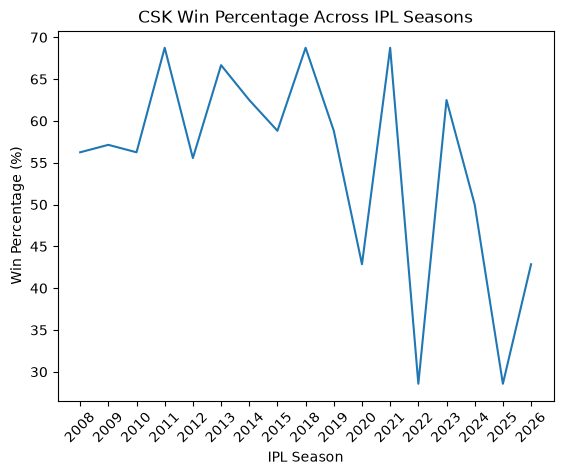

In [43]:
sn.lineplot(x=win_percent_per_season.index, y=win_percent_per_season.values)

plt.xlabel("IPL Season")
plt.ylabel("Win Percentage (%)")
plt.title("CSK Win Percentage Across IPL Seasons")

plt.xticks(rotation=45)

plt.show()

In [44]:
### Inference

# The line chart shows CSK's overall win percentage across IPL seasons from 2008 to 2026. The highest win percentage was recorded in 2011 and 2021, at above 68%, while the lowest was recorded in 2025, at around 28%. CSK's win percentage remained relatively stable during several seasons up to 2019, followed by greater fluctuations in the subsequent seasons.


#### 2. Opponent-wise Wins

****Question:**** How many matches has CSK won against each opponent?


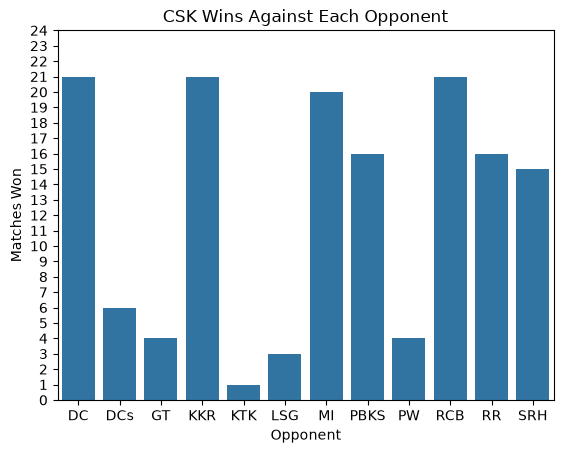

In [45]:
sn.barplot(x=win_against_each_team.index, y=win_against_each_team.values)
plt.yticks(range(0, 25))
plt.xlabel("Opponent")
plt.ylabel("Matches Won")
plt.title("CSK Wins Against Each Opponent")

plt.show()

In [46]:
### Inference

# This bar chart shows the number of matches CSK has won against each opponent. CSK have won the most matches against Delhi Capitals (DC), Kolkata Knight Riders (KKR), and Royal Challengers Bengaluru (RCB), with 21 wins against each team.

#### 3. Opponent-wise Wins and Losses

****Question:**** How do CSK's wins and losses compare against each opponent?


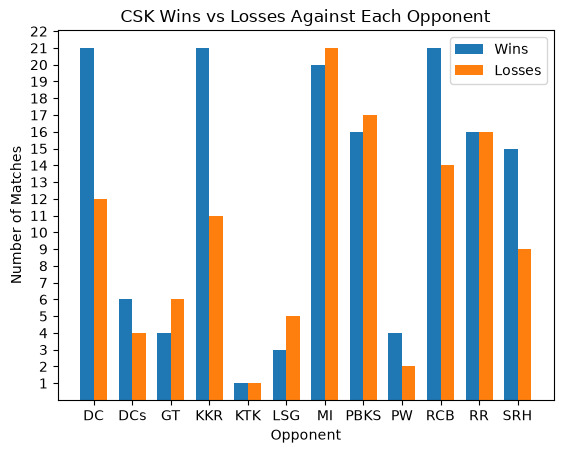

In [47]:
x = np.arange(len(win_against_each_team.index))
width = 0.35

plt.bar(x - width / 2, win_against_each_team.values, width, label="Wins") # left side

plt.bar(x + width / 2, loss_against_each_team.values, width, label="Losses") # right side

plt.xticks(x, win_against_each_team.index)
plt.yticks(range(1,23,1))

plt.xlabel("Opponent")
plt.ylabel("Number of Matches")
plt.title("CSK Wins vs Losses Against Each Opponent")

plt.legend()
plt.show()

In [48]:
### Inference

# CSK have won the most matches against DC, RCB, and KKR, with 21 wins against each team. CSK have played the most matches against MI, with 41 matches, winning 20 of them. GT and LSG have won more matches against CSK than CSK have won against them. Against RR, CSK have an equal number of wins and losses, resulting in a 50% win rate.

#### 4. Win Percentage Against Each Opponent

****Question**** : What is CSK's win percentage against each opponent?

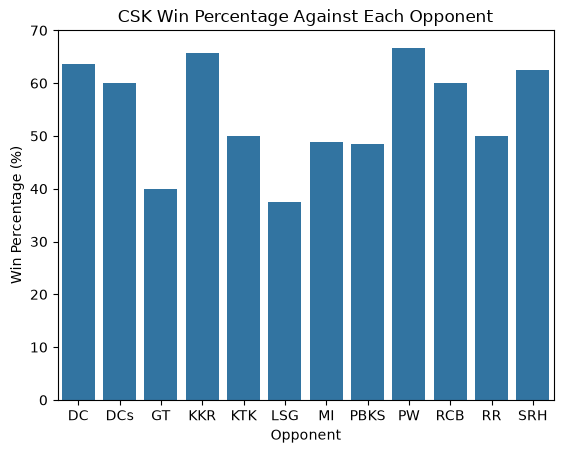

In [49]:
sn.barplot(x=win_percent_each_team.index, y=win_percent_each_team.values)

plt.xlabel("Opponent")
plt.ylabel("Win Percentage (%)")
plt.title("CSK Win Percentage Against Each Opponent")

plt.show()

In [50]:
### Inference

# This bar chart shows CSK's win percentage against each opponent. However, these win percentages should be interpreted with caution because the teams have not all been part of the IPL for the same number of seasons. Some teams, such as DCs, KTK, and PW, are no longer part of the IPL, while teams such as GT and LSG joined more recently. Therefore, differences in win percentage may partly reflect the number of matches played against each opponent.

#### 4. Win Percentage Against Frequent Opponents

****Question:**** What is CSK's win percentage against teams they have played at least 15 matches against?

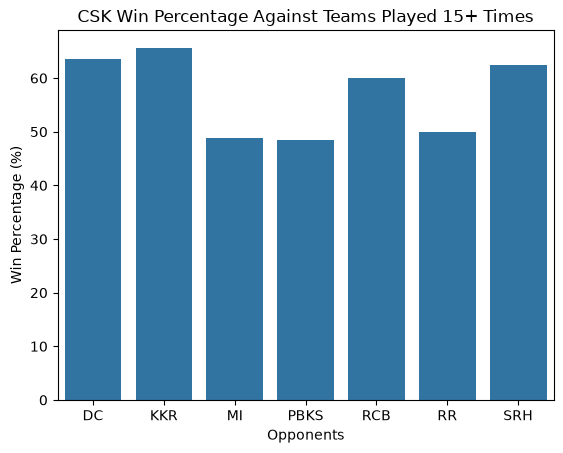

In [51]:
idx = matches_against_team[matches_against_team>=15].index

val = win_percent_each_team[idx].values 

sn.barplot(x=idx,y=val)
plt.title("CSK Win Percentage Against Teams Played 15+ Times")
plt.xlabel("Opponents")
plt.ylabel("Win Percentage (%)")
plt.show()

In [ ]:
### Inference

# This bar chart shows CSK's win percentage against the opponents they have played at least 15 matches against. CSK have the highest win percentage against KKR at around 66%, followed by DC at around 62%. CSK have a win percentage above 50% against KKR, DC, RCB, and SRH. Against MI and PBKS, CSK have a win percentage of around 48%, while their win percentage against RR is 50%, indicating an equal number of wins and losses.


In [52]:
win_percent_each_team

opponent_abbr
DC      63.64
DCs     60.00
GT      40.00
KKR     65.62
KTK     50.00
LSG     37.50
MI      48.78
PBKS    48.48
PW      66.67
RCB     60.00
RR      50.00
SRH     62.50
dtype: float64

#### 5. M.O.M. Awards Distribution

****Question:**** Which players have received the most M.O.M. awards in CSK matches?

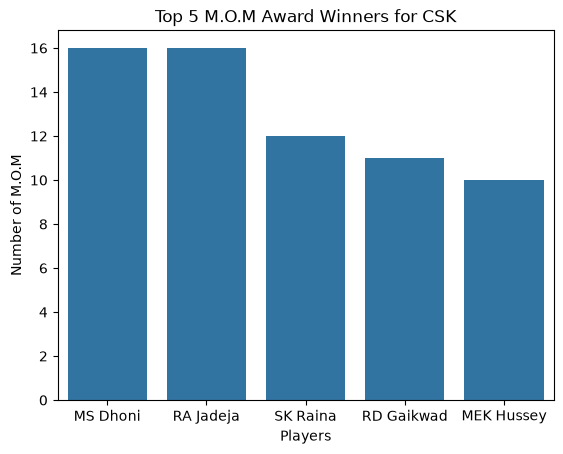

In [65]:
# Top 5 players with most M.O.M awards

top5 = mom_counts.head()

sn.barplot(x=top5.index,y=top5.values)
plt.title("Top 5 M.O.M Award Winners for CSK")
plt.xlabel("Players")
plt.ylabel("Number of M.O.M")
plt.show()

In [67]:
### Inference

# This bar chart shows the top 5 CSK players with the most M.O.M. awards. Mahendra Singh Dhoni and Ravindra Jadeja have won the most awards, with 16 M.O.M. awards each, followed by Suresh Raina with 12 awards. Ruturaj Gaikwad has won 11 awards despite playing fewer matches than the other four players.


#### 6. Season-wise League-Stage Finishing Position

****Question:**** What was CSK's league-stage finishing position in each IPL season?

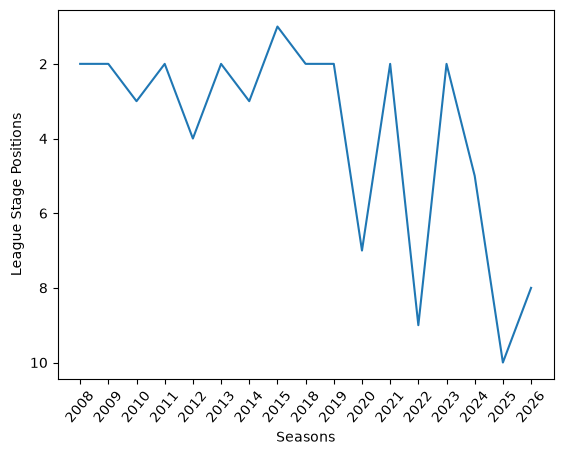

In [78]:
sn.lineplot(x=season_result.index,y=season_result.league_stage)
plt.xlabel("Seasons")
plt.ylabel("League Stage Positions")
plt.xticks(rotation=50)
plt.gca().invert_yaxis()
plt.show()

In [86]:
### Inference

# This line chart shows CSK's league-stage finishing position across different IPL seasons. CSK finished in 1st position once, in 2015, and finished in 2nd position 8 times. Their lowest league-stage finish was 10th position in 2025.

#### 7. Championship and Runner-up Finishes

****Question:**** What proportion of CSK's playoff seasons ended as Champions or Runner-up?

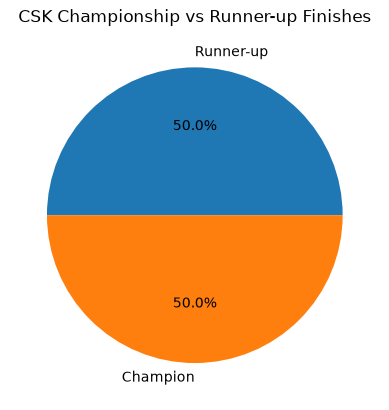

In [96]:
final_results_count = season_result[season_result["final_result"].isin(["Champion","Runner-up"])]

plt.pie(
    final_results_count["final_result"].value_counts().values,
    labels=final_results_count["final_result"].value_counts().index,
    autopct="%1.1f%%"
)
plt.title("CSK Championship vs Runner-up Finishes")
plt.show()

In [ ]:
### Inference 

# This pie chart shows CSK's final results in the IPL. CSK have played 10 IPL finals, winning 5 and finishing as Runner-up in 5. This gives CSK a 50% win percentage in IPL finals.

#### 8. Venue-wise Performance

****Question:**** How has CSK performed at different venues in the IPL?

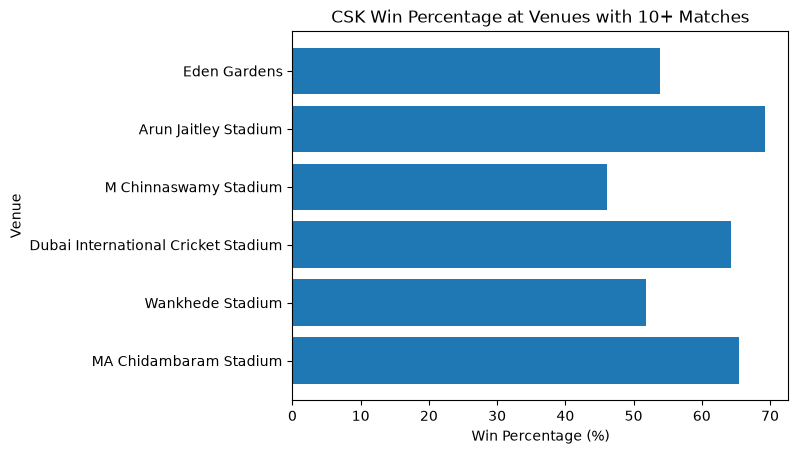

In [140]:
# Count how many matches CSK played at each venue
# Example: Chepauk -> 84 matches, Wankhede -> 27 matches, etc.
venue_matches = csk_data["venue"].value_counts()


# Keep only those venues where CSK played at least 10 matches
# This gives us the venues we want to analyse
venue_matches = venue_matches[venue_matches >= 10]


# Select only the matches that CSK WON
# Then group those wins by venue
# Example: Chepauk -> 50 wins, Wankhede -> 12 wins, etc.
win_by_venue = (
    csk_data[csk_data["winner"] == "Chennai Super Kings"].groupby("venue").size()
)


# Make sure win_by_venue has the SAME venues as venue_matches
# Why?
# Some venues may have 10+ total matches but CSK may have won 0 matches there.
# Such a venue will NOT appear in win_by_venue.
# reindex() adds those missing venues
# fill_value=0 means: if CSK has no wins at that venue, put 0.
win_by_venue = win_by_venue.reindex(venue_matches.index, fill_value=0)


# Calculate win percentage for each venue
win_percent = (win_by_venue / venue_matches) * 100


# Round the percentages to 2 decimal places
win_percent = win_percent.round(2)

win_percent


plt.barh(
    win_percent.index, # Y axis
    win_percent.values, # X axis
)

plt.xlabel("Win Percentage (%)")
plt.ylabel("Venue")
plt.title("CSK Win Percentage at Venues with 10+ Matches")

plt.show()

In [ ]:
### Inference

# This bar chart shows CSK's win percentage at venues where they have played at least 10 matches. CSK have their highest win percentage at Arun Jaitley Stadium, at around 70%. At MA Chidambaram Stadium, CSK have a win percentage of around 65%, while their win percentage at M Chinnaswamy Stadium is around 46%. MA Chidambaram Stadium has hosted the most CSK matches, as it is their home venue in Chennai.

## Conclusion

This project provided an exploratory analysis of Chennai Super Kings' performance across IPL seasons from 2008 to 2026. The analysis covered season-wise performance, opponent-wise results, M.O.M. awards, league-stage finishes, final results, and venue-wise performance.

The analysis showed that CSK's performance has varied across seasons, opponents, and venues. CSK have maintained a strong record against several long-term opponents, while their win percentage has differed across teams and venues. The analysis also highlighted CSK's consistency in reaching the later stages of the tournament, with 10 IPL final appearances, including 5 championships and 5 runner-up finishes.

Overall, this project helped me apply the core concepts of **NumPy, Pandas, Matplotlib, and Seaborn** to a real-world dataset. It also provided practical experience with data cleaning, standardization, filtering, grouping, aggregation, and data visualization.


## Limitations

* The analysis is based on the available match-level dataset, so missing or incorrect records in the source data may affect the results.
* Some team and venue names appeared in different formats and required manual standardization before analysis.
* Teams have not all participated in the IPL for the same number of seasons, so opponent-wise win percentages should be interpreted alongside the number of matches played.
* Venue-wise analysis was restricted to venues where CSK played at least 10 matches to avoid conclusions based on very small sample sizes.
* The analysis focuses on match-level results and does not include factors such as player injuries, playing XI changes, weather conditions, toss decisions, or individual match circumstances.
* League-stage finishing positions and final results were manually compiled for this project and may require verification against official IPL records.
* The project is descriptive in nature and does not include predictive modelling or statistical testing.


## Key Learnings

* Learned to clean and standardize real-world data using **Pandas**.
* Practiced **filtering, grouping, aggregation, and data transformation**.
* Learned to use **Boolean indexing, `value_counts()`, `groupby()`, and `reindex()`**.
* Learned to choose appropriate charts based on the type of analysis.
* Gained practical experience with **Matplotlib and Seaborn**.
* Learned to interpret visualizations and extract meaningful insights.
* Understood the importance of **data quality, sample size, and limitations** in EDA.
* Learned how to follow a complete **EDA workflow from understanding and cleaning the data to analyzing, visualizing, and communicating insights**.


## Personal Note 🦁💛

Picked CSK for this project because they are my favourite team!
What better way to learn EDA than by analysing a team I have followed and supported for years?

From analysing seasons, wins, losses, opponents, venues, and M.O.M. awards, this project was a fun way to turn my interest in cricket into a data analysis project.

**Whistle Podu! 🦁💛**

**2027 — Bring it home! 🏆💛**
